# **EDA: Disaster Tweets** — Notebook 1 (Medium-inspired)

**Overview.** This notebook is a student-friendly exploratory data analysis (EDA) companion to the Medium article "Natural Language Processing with Disaster Tweets — Part 1". The original post focuses on building a baseline model; this notebook complements it by walking through practical EDA tasks that help you better understand the dataset before modeling.

**Dataset.** Kaggle competition: *nlp-getting-started* (train.csv contains `id`, `text`, `keyword`, `location`, `target`).

**Instructions for students.** Run each cell, read the comments, and complete the exercises. Files expected: `train.csv`, `test.csv` in the working directory.

## 1) Setup & quick load

Install packages (only if needed) and load the CSV into a DataFrame. We keep lines concise and heavily commented.

In [1]:
!pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from collections import Counter

### **Dataset**

In [2]:
train_path =  r'nlp-getting-started/train.csv' 

try:
    df = pd.read_csv(train_path)
except FileNotFoundError:
    raise FileNotFoundError("train.csv not found. Please place the Kaggle 'train.csv' file in the notebook working directory.")


In [3]:

print('Rows, columns:', df.shape)
df.head()


Rows, columns: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


This show us that the dataset has 7613 Rows and 5 Columns:
- id
- keyword
- location
- text
- target

In [4]:
df.shape

(7613, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 1.2 MB


## 2) Basic checks and metadata
Check for missing values, data types, and distribution of the target label. These quick checks help decide preprocessing steps.

**2.1 Check for missing values and data types**

In [6]:
df.dtypes

id          int64
keyword       str
location      str
text          str
target      int64
dtype: object

In [7]:
print('\nMissing values per column:\n', df.isnull().sum())


Missing values per column:
 id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [8]:
print('Percentage of missing values per column:')
(df.isnull().mean() * 100).round(2)

Percentage of missing values per column:


id           0.00
keyword      0.80
location    33.27
text         0.00
target       0.00
dtype: float64

The location column contains substantial missing values and free-form text, making it noisy. It may not be reliable for modeling without significant preprocessing.

**2.2. Cardinality and unique values**

In [9]:
print("Unique users", df['id'].value_counts().shape[0])
print("Locations", df['location'].value_counts().shape[0])

Unique users 7613
Locations 3341


In [10]:
texts = df['text']
number_of_hastags = 0
for text in texts:
    number_of_hastags += len(re.findall(r'#\w+', text))

print(f"Number of hashtags: ", number_of_hastags)
print("Number of labels: ", df['target'].value_counts().shape[0])

Number of hashtags:  3330
Number of labels:  2


**2.3 Duplicated tweets and retweets**

First we checks duplicates based only on text

In [11]:
duplicated = df[df.duplicated(subset=['text'], keep=False)]
duplicated

,id,keyword,location,text,target
40,59,ablaze,Live On Webcam,Check these out: http://t.co/rOI2NSmEJJ http:/...,0
48,68,ablaze,Live On Webcam,Check these out: http://t.co/rOI2NSmEJJ http:/...,0
106,156,aftershock,US,320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/vA...,0
115,165,aftershock,US,320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/vA...,0
118,171,aftershock,Switzerland,320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/TH...,0
...,...,...,...,...,...
7600,10855,NaN,NaN,Evacuation order lifted for town of Roosevelt:...,1
7607,10867,NaN,NaN,#stormchase Violent Record Breaking EF-5 El Re...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1


We maintain all duplicated values, beacuse we want to know if duplicated records have different targets

In [12]:
# With this codeline we can know how many duplicated text have more than one target, in other words, how many duplicated text have different target values
duplicated_target = duplicated.groupby('text', as_index=False)['target'].nunique()
duplicated_target

,text,target
0,#Allah describes piling up #wealth thinking it...,2
1,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
2,#KCA #VoteJKT48ID 12News: UPDATE: A family of ...,1
3,#Myanmar Displaced #Rohingya at #Sittwe point...,1
4,#Newswatch: 2 vehicles collided at Lock and La...,1
...,...,...
64,incident with injury:I-495 inner loop Exit 31...,1
65,like for the music video I want some real acti...,2
66,that exploded &amp; brought about the\nbeginni...,1
67,that horrible sinking feeling when youÛªve be...,2


In [13]:
#here we can see that are 69 duplicated text with more than one target value
duplicated_focus_target = duplicated.groupby('text', as_index=False)['target'].nunique()
duplicated_focus_target


,text,target
0,#Allah describes piling up #wealth thinking it...,2
1,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
2,#KCA #VoteJKT48ID 12News: UPDATE: A family of ...,1
3,#Myanmar Displaced #Rohingya at #Sittwe point...,1
4,#Newswatch: 2 vehicles collided at Lock and La...,1
...,...,...
64,incident with injury:I-495 inner loop Exit 31...,1
65,like for the music video I want some real acti...,2
66,that exploded &amp; brought about the\nbeginni...,1
67,that horrible sinking feeling when youÛªve be...,2


In [14]:

duplicated_with_multiple_targets = duplicated_focus_target[duplicated_focus_target['target'] > 1]
duplicated_with_multiple_targets

,text,target
0,#Allah describes piling up #wealth thinking it...,2
7,#foodscare #offers2go #NestleIndia slips into ...,2
11,.POTUS #StrategicPatience is a strategy for #G...,2
24,CLEARED:incident with injury:I-495 inner loop...,2
25,Caution: breathing may be hazardous to your he...,2
32,He came to a land which was engulfed in tribal...,2
33,Hellfire is surrounded by desires so be carefu...,2
35,Hellfire! We donÛªt even want to think about ...,2
37,I Pledge Allegiance To The P.O.P.E. And The Bu...,2
39,In #islam saving a person is equal in reward t...,2


In [15]:
df = df[~df['text'].isin(duplicated_with_multiple_targets['text'])]
df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


 We drop the records that are Retweets, to check if the text have RT or @ in the beggining of the text

In [16]:
df = df[~(df['text'].str.startswith('RT') | df['text'].str.startswith('@'))]
df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7607,10867,NaN,NaN,#stormchase Violent Record Breaking EF-5 El Re...,1
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


**2.4 Missing or empty tweets and retweets** 

In [17]:
def empty_tweets(df):
    empty_tweets = df[df['text'].str.len() == 0]
    if not empty_tweets.empty:
        print("Empty tweets found:")
        print(empty_tweets)
    else:
        print("No empty tweets found.")
    return empty_tweets

empty_tweets(df)

No empty tweets found.


,id,keyword,location,text,target


**2.2 Distribution of the target variable**

In [18]:
print('\nTarget value counts:')
print(df['target'].value_counts())

# Ratio of disaster vs not-disaster
print('\nTarget proportions:')
print(df['target'].value_counts(normalize=True))



Target value counts:
target
0    3352
1    2815
Name: count, dtype: int64

Target proportions:
target
0    0.543538
1    0.456462
Name: proportion, dtype: float64


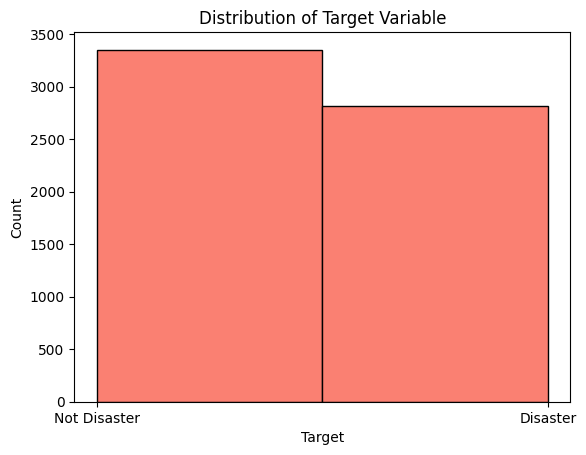

In [19]:
plt.hist(df['target'], bins=2, edgecolor='black', color=['salmon'])
plt.xticks([0, 1], ['Not Disaster', 'Disaster'])
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Distribution of Target Variable')
plt.show()

## 3) Text length and simple text statistics
Compute tweet lengths and visualise simple statistics. These features often help in downstream models.
 - Tasks: character length, token length distributions
    
- Purpose: identify outliers and truncation risks.

In [20]:
df['text'] = df['text'].astype(str)
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

These codelines ensure that 'text' is string type and create Text length (characters) and token counts (whitespace split)
columns 

In [21]:
print(df[['char_count','word_count']].describe())

        char_count   word_count
count  6167.000000  6167.000000
mean    101.921031    14.790984
std      32.990294     5.517459
min       7.000000     1.000000
25%      79.000000    11.000000
50%     107.000000    15.000000
75%     133.500000    19.000000
max     157.000000    31.000000


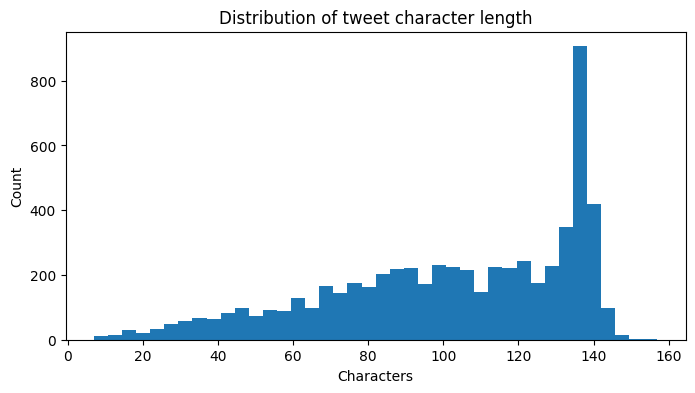

In [22]:
plt.figure(figsize=(8,4))
plt.hist(df['char_count'], bins=40)
plt.title('Distribution of tweet character length')
plt.xlabel('Characters')
plt.ylabel('Count')
plt.show()


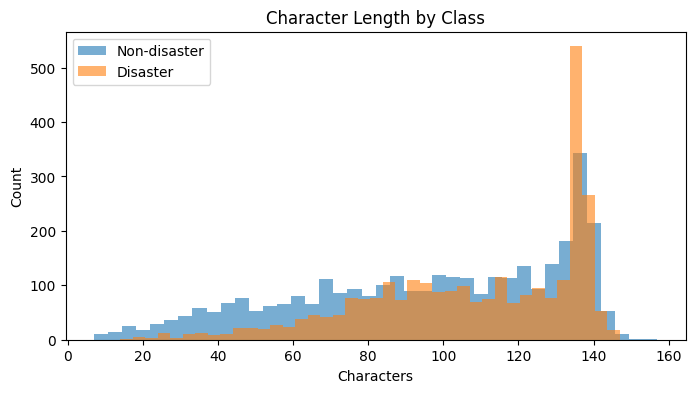

In [23]:
plt.figure(figsize=(8,4))
plt.hist(df[df['target']==0]['char_count'], bins=40, alpha=0.6, label='Non-disaster')
plt.hist(df[df['target']==1]['char_count'], bins=40, alpha=0.6, label='Disaster')
plt.legend()
plt.title('Character Length by Class')
plt.xlabel('Characters')
plt.ylabel('Count')
plt.show()

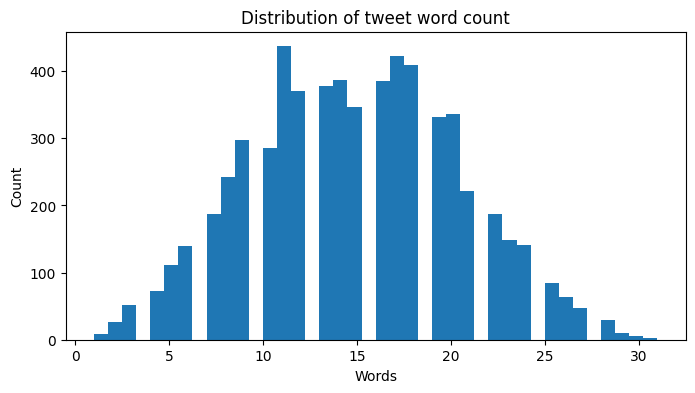

In [24]:
plt.figure(figsize=(8,4))
plt.hist(df['word_count'], bins=40)
plt.title('Distribution of tweet word count')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()


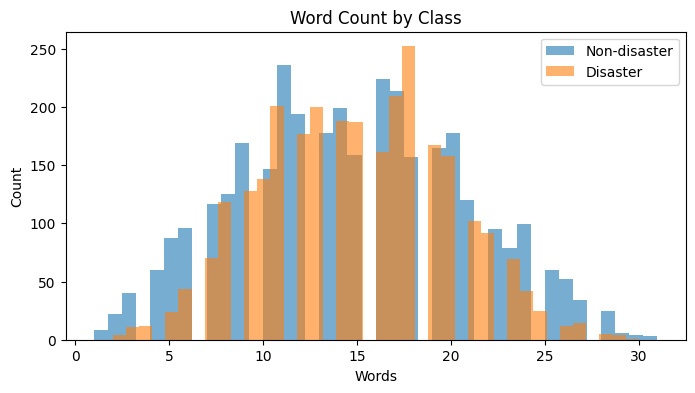

In [25]:
plt.figure(figsize=(8,4))
plt.hist(df[df['target']==0]['word_count'], bins=40, alpha=0.6, label='Non-disaster')
plt.hist(df[df['target']==1]['word_count'], bins=40, alpha=0.6, label='Disaster')
plt.legend()
plt.title('Word Count by Class')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

In [26]:
df.groupby('target')[['char_count','word_count']].mean()

,char_count,word_count
target,,
0,96.467184,14.631563
1,108.415275,14.980817


In [27]:
df.groupby('target')[['char_count','word_count']].median()

,char_count,word_count
target,,
0,102.0,14.0
1,114.0,15.0



We compute the most frequent tokens overall and per class. This helps spot domain-specific vocabulary (e.g., 'earthquake', 'flood').

**Auxiliary functions for text cleaning and tokenisation**

In [28]:
# Simple tokeniser: lowercase, remove URLs and punctuation, split on whitespace
url_regex = r'http\S+'

def simple_tokenize(text):
    '''Basic tokenization: lowercase, remove URLs and punctuation, split on whitespace
    '''
    text = re.sub(url_regex, '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    tokens = text.lower().split()
    return tokens

def get_top_tokens(texts, n=20):
    '''Get top n tokens from a list of texts
    '''
    all_tokens = []
    for text in texts:
        all_tokens.extend(simple_tokenize(text))
    token_counts = Counter(all_tokens)
    return token_counts.most_common(n)

def tockens_counts_by_target(df, target_value):
    '''Get top tokens for a specific target value (0 or 1)'''
    target_texts = df[df['target'] == target_value]['text']
    return get_top_tokens(target_texts)


def graph_top_tokens(token_counts, title):
    tokens, counts = zip(*token_counts)
    plt.figure(figsize=(10,5))
    plt.bar(tokens, counts, color='pink')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.ylabel('Count')
    plt.title(f' {title}')
    plt.show()



In [29]:
df['tokens'] = df['text'].apply(simple_tokenize)
df[['text','tokens']].head()

,text,tokens
0,Our Deeds are the Reason of this #earthquake M...,"[our, deeds, are, the, reason, of, this, earth..."
1,Forest fire near La Ronge Sask. Canada,"[forest, fire, near, la, ronge, sask, canada]"
2,All residents asked to 'shelter in place' are ...,"[all, residents, asked, to, shelter, in, place..."
3,"13,000 people receive #wildfires evacuation or...","[13, 000, people, receive, wildfires, evacuati..."
4,Just got sent this photo from Ruby #Alaska as ...,"[just, got, sent, this, photo, from, ruby, ala..."


In [30]:
df["token_numbers"] = df['tokens'].apply(len)
df[["text","token_numbers"]].head()

,text,token_numbers
0,Our Deeds are the Reason of this #earthquake M...,13
1,Forest fire near La Ronge Sask. Canada,7
2,All residents asked to 'shelter in place' are ...,22
3,"13,000 people receive #wildfires evacuation or...",9
4,Just got sent this photo from Ruby #Alaska as ...,16


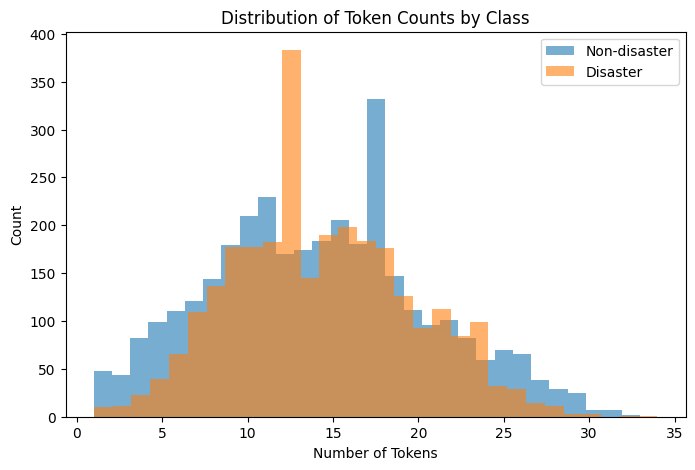

In [31]:
plt.figure(figsize=(8,5))

plt.hist(
    df[df['target']==0]['token_numbers'],
    bins=30,
    alpha=0.6,
    label='Non-disaster'
)

plt.hist(
    df[df['target']==1]['token_numbers'],
    bins=30,
    alpha=0.6,
    label='Disaster'
)

plt.title('Distribution of Token Counts by Class')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.legend()
plt.show()

In [32]:

print("Top 20 tokens overall:") 
tockens = get_top_tokens(df['text'], n=20)
tockens

Top 20 tokens overall:


[('the', 2581),
 ('a', 1761),
 ('in', 1701),
 ('to', 1525),
 ('of', 1495),
 ('i', 1247),
 ('and', 1093),
 ('s', 801),
 ('for', 720),
 ('is', 714),
 ('on', 710),
 ('my', 564),
 ('you', 557),
 ('it', 524),
 ('at', 480),
 ('with', 446),
 ('by', 438),
 ('that', 423),
 ('this', 368),
 ('from', 358)]

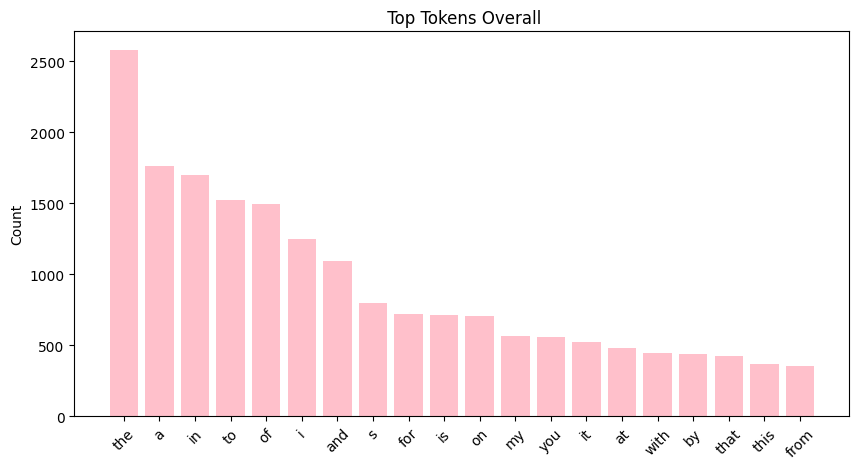

In [33]:
graph_top_tokens(tockens, title="Top Tokens Overall")


Top tokens for non-disaster tweets (target=0):


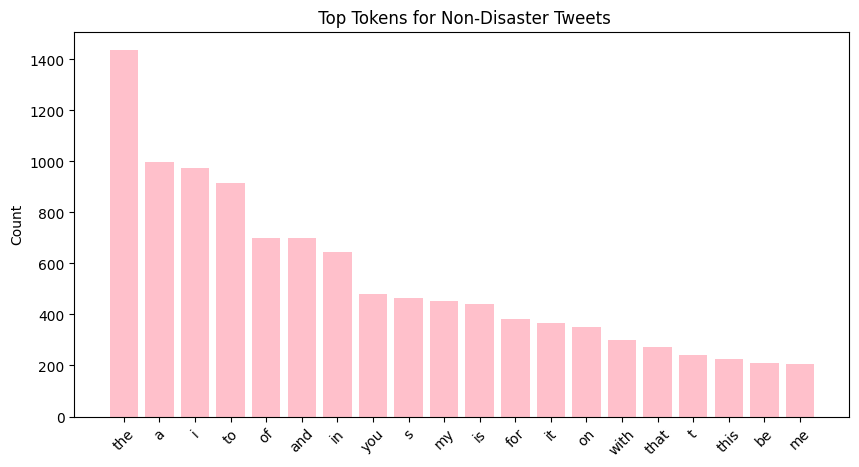

In [34]:
print("\nTop tokens for non-disaster tweets (target=0):")
non_disaster_tokens = tockens_counts_by_target(df, target_value=0)
graph_top_tokens(non_disaster_tokens, title="Top Tokens for Non-Disaster Tweets")


Top tokens for disaster tweets (target=1):


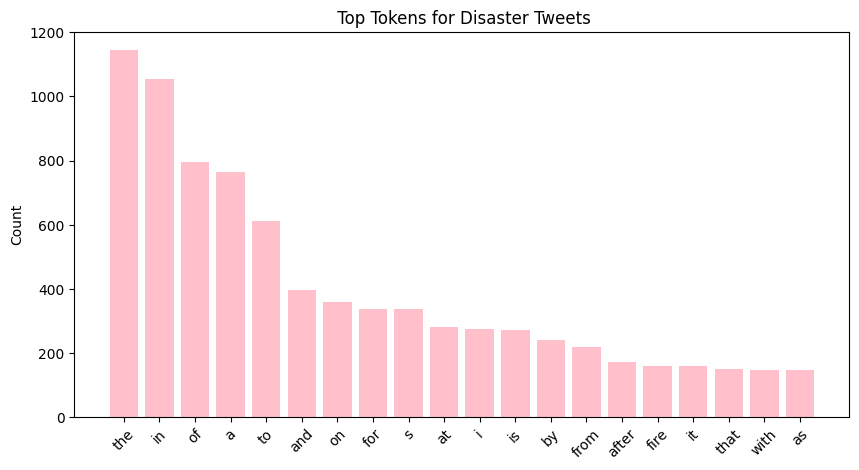

In [35]:
print("\nTop tokens for disaster tweets (target=1):")
disaster_tokens = tockens_counts_by_target(df, target_value=1)
graph_top_tokens(disaster_tokens, title="Top Tokens for Disaster Tweets")

**2.6 URLs, mentions, hashtags, emojis extraction**

    - Tasks: extract and count each element separately

    - Purpose: these are often informative features.

In [ ]:
df['has_url'] = df['text'].str.contains(r'http[s]?://', regex=True).astype(int)
df.sample(5)

,id,keyword,location,text,target,char_count,word_count,tokens,token_numbers,has_url
6686,9580,thunder,NaN,Heavy rain frequent thunder and gusty winds mo...,1,135,18,"[heavy, rain, frequent, thunder, and, gusty, w...",15,True
4628,6577,injury,"Dallas, TX",#Cowboys: George: Injury woes took Claiborne f...,0,127,19,"[cowboys, george, injury, woes, took, claiborn...",18,True
106,156,aftershock,US,320 [IR] ICEMOON [AFTERSHOCK] | http://t.co/vA...,0,138,16,"[320, ir, icemoon, aftershock, djicemoon, dubs...",11,True
3527,5041,eyewitness,Los Angeles... CA... USA,Aug. 06 2015 Radio Show articles ÛÒ \n1] Eye...,0,135,18,"[aug, 06, 2015, radio, show, articles, 1, eyew...",16,True
637,923,bioterrorism,NaN,The #IranDeal only covers nuclear activity. Wh...,1,129,20,"[the, irandeal, only, covers, nuclear, activit...",20,False


In [ ]:

df['url_count'] = df['text'].str.count(r'http[s]?://')

In [44]:
df['has_url'].value_counts()

has_url
1    3815
0    2352
Name: count, dtype: int64

In [ ]:
df['url_count'] = df['url_count'].apply(len)
df.sample(5)

,id,keyword,location,text,target,char_count,word_count,tokens,token_numbers,has_url,url_count
6546,9367,survived,"Port Harcourt, Nigeria",Nigerian boxer ?who survived sessions with Kli...,0,101,12,"[nigerian, boxer, who, survived, sessions, wit...",11,True,0
967,1399,body%20bag,New York,AUTH LOUIS VUITTON BROWN SAUMUR 35 CROSS BODY ...,0,139,18,"[auth, louis, vuitton, brown, saumur, 35, cros...",17,True,0
1376,1985,bush%20fires,Melbourne Australia,The Public Health Team was traumatised after t...,1,128,16,"[the, public, health, team, was, traumatised, ...",15,True,0
3592,5131,fatal,"New South Wales, Australia",Man charged over fatal crash near Dubbo refuse...,1,93,12,"[man, charged, over, fatal, crash, near, dubbo...",11,True,0
1613,2330,collapse,NaN,mentions of 'theatre +shooting' on Twitter spi...,1,101,13,"[mentions, of, theatre, shooting, on, twitter,...",12,True,0


In [45]:
df['url_count'].head()
df['url_count'].describe()

count    6167.000000
mean        0.735366
std         0.661498
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: url_count, dtype: float64

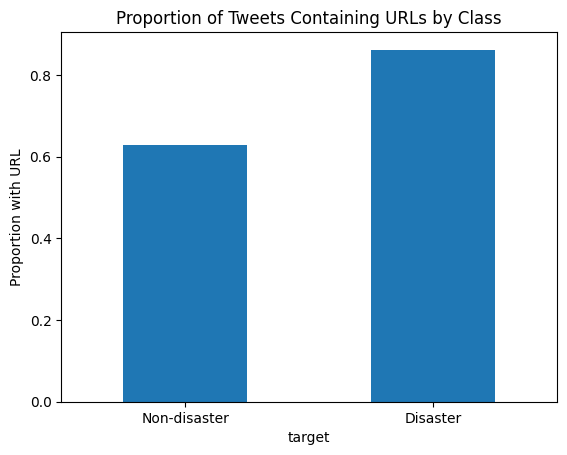

In [47]:
url_by_class = df.groupby('target')['url_count'].mean()

url_by_class.plot(kind='bar')
plt.title('Proportion of Tweets Containing URLs by Class')
plt.ylabel('Proportion with URL')
plt.xticks([0,1], ['Non-disaster','Disaster'], rotation=0)
plt.show()

In [48]:
df['has_mentions'] = df['text'].str.contains(r'@\w+', regex=True)
df['mentions_count'] = df['text'].str.findall(r'@\w+')
df['mentions_count'] = df['mentions_count'].apply(len)
df.sample(3)

,id,keyword,location,text,target,char_count,word_count,tokens,token_numbers,has_url,url_count,has_mentions,mentions_count
480,690,attack,Global,[infowars] Nashville Theater Attack: Will Gun...,1,117,13,"[infowars, nashville, theater, attack, will, g...",12,1,1,False,0
3668,5222,fatality,Boston Û¢ Cape Cod ?,Dying of Lyme disease: Case fatality rate near...,1,76,10,"[dying, of, lyme, disease, case, fatality, rat...",9,1,1,False,0
4727,6723,lava,NaN,I liked a @YouTube video from @skippy6gaming h...,0,132,25,"[i, liked, a, youtube, video, from, skippy6gam...",19,1,1,True,2


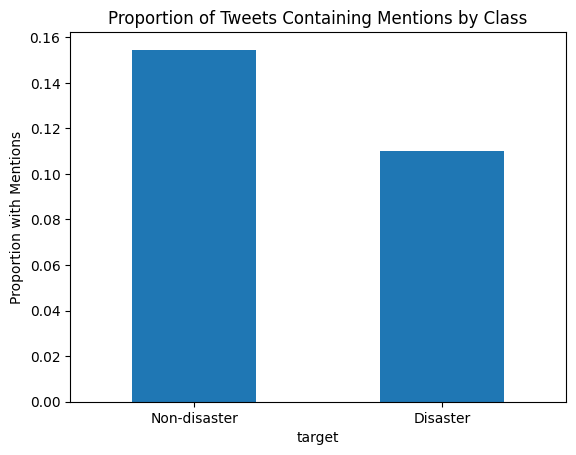

In [49]:
mentions = df.groupby('target')['mentions_count'].mean()

mentions.plot(kind='bar')
plt.title('Proportion of Tweets Containing Mentions by Class')
plt.ylabel('Proportion with Mentions')
plt.xticks([0,1], ['Non-disaster','Disaster'], rotation=0)
plt.show()

In [50]:
df['has_hashtags'] = df['text'].str.contains(r'#\w+', regex=True)
df['hashtags_count'] = df['text'].str.findall(r'#\w+')
df['hashtags_count'] = df['hashtags_count'].apply(len)
df.sample(5)

,id,keyword,location,text,target,char_count,word_count,tokens,token_numbers,has_url,url_count,has_mentions,mentions_count,has_hashtags,hashtags_count
6481,9268,sunk,NAIROBI KENYA,#ArrestpastorNganga it so worrying 2 see how s...,0,139,24,"[arrestpastornganga, it, so, worrying, 2, see,...",24,0,0,False,0,True,1
5615,8012,refugees,"Aurora, Ontario",Turkish newlyweds donate wedding money - what ...,0,119,16,"[turkish, newlyweds, donate, wedding, money, w...",14,1,1,False,0,False,0
1796,2576,crash,NaN,cPanel Crash Course http://t.co/bIRKbje23e #co...,0,73,6,"[cpanel, crash, course, course]",4,1,2,False,0,True,1
2761,3967,devastation,"Washington, DC",70 Years After Atomic Bombs Japan Still Strugg...,1,139,20,"[70, years, after, atomic, bombs, japan, still...",19,1,1,False,0,False,0
3943,5605,flood,Waddesdon,Chinese rescue team arrives in Myanmar to help...,1,114,13,"[chinese, rescue, team, arrives, in, myanmar, ...",11,1,2,False,0,False,0


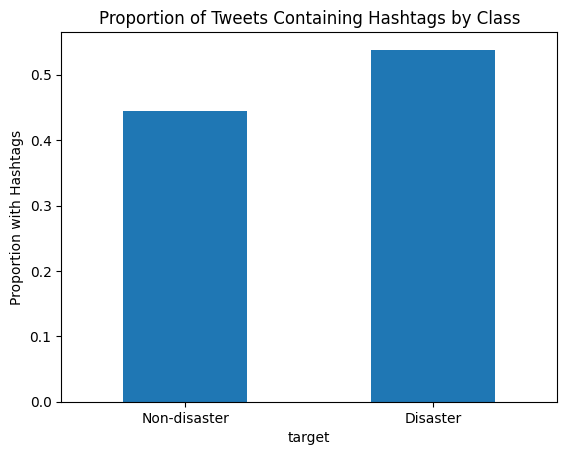

In [51]:
mentions = df.groupby('target')['hashtags_count'].mean()

mentions.plot(kind='bar')
plt.title('Proportion of Tweets Containing Hashtags by Class')
plt.ylabel('Proportion with Hashtags')
plt.xticks([0,1], ['Non-disaster','Disaster'], rotation=0)
plt.show()

**2.7 Emoji extraction and analysis**

In [54]:
!pip install emoji

   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 608.4/608.4 kB 7.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import emoji

In [60]:
def find_emojis(text):
    emojis = []
    for ch in text:
        if emoji.is_emoji(ch):
            emojis.append(ch)
    return emojis

def has_emojis(text):
    return any(emoji.is_emoji(ch) for ch in text)

In [61]:
df['has_emojis'] = df['text'].apply(has_emojis)
df['emoji_count'] = df['text'].apply(find_emojis)
df['emoji_count'] = df['emoji_count'].apply(len)
df.head()

,id,keyword,location,text,target,char_count,word_count,tokens,token_numbers,has_url,url_count,has_mentions,mentions_count,has_hashtags,hashtags_count,has_emojis,emoji_count
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,69,13,"[our, deeds, are, the, reason, of, this, earth...",13,0,0,False,0,True,1,False,0
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38,7,"[forest, fire, near, la, ronge, sask, canada]",7,0,0,False,0,False,0,False,0
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,133,22,"[all, residents, asked, to, shelter, in, place...",22,0,0,False,0,False,0,False,0
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,65,8,"[13, 000, people, receive, wildfires, evacuati...",9,0,0,False,0,True,1,False,0
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,88,16,"[just, got, sent, this, photo, from, ruby, ala...",16,0,0,False,0,True,2,False,0


In [ ]:
emoji_by_class = df.groupby('target')['emoji_count'].mean()
emoji_by_class

target
0    0.000000
1    0.003197
Name: emoji_count, dtype: float64

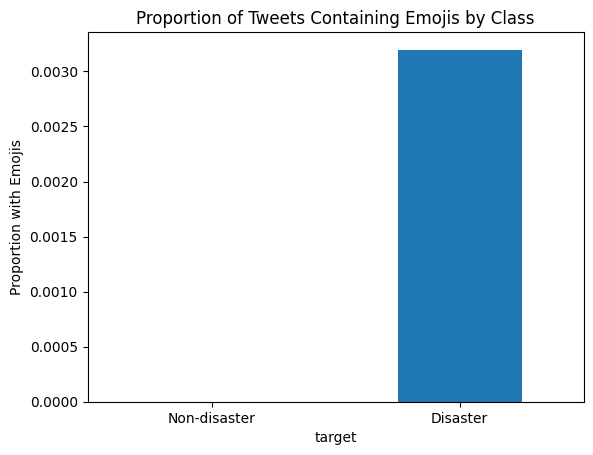

In [63]:
mentions = df.groupby('target')['emoji_count'].mean()

mentions.plot(kind='bar')
plt.title('Proportion of Tweets Containing Emojis by Class')
plt.ylabel('Proportion with Emojis')
plt.xticks([0,1], ['Non-disaster','Disaster'], rotation=0)
plt.show()

**2.7 Missing values in `keyword` and `location`**

These columns contain many missing values; decide whether to keep them, impute, or drop them depending on your approach.

In [52]:
df['keyword'].value_counts()

keyword
fatalities               42
collided                 39
wreckage                 39
outbreak                 38
collision                37
                         ..
mass%20murder            16
epicentre                 9
radiation%20emergency     9
threat                    9
inundation                8
Name: count, Length: 221, dtype: int64

In [205]:
print(df['keyword'].isnull().sum(), 'missing keywords out of', len(df))
print(df['location'].isnull().sum(), 'missing locations out of', len(df))

# Quick peek at some non-null keywords
print('\nSample keywords:')
print(df['keyword'].dropna().sample(10).tolist())

print('\nSample locations:')
print(df['location'].dropna().sample(10).tolist())


59 missing keywords out of 6167
2075 missing locations out of 6167

Sample keywords:
['accident', 'evacuation', 'casualty', 'sinking', 'collision', 'sinkhole', 'injured', 'twister', 'natural%20disaster', 'snowstorm']

Sample locations:
['Sydney', 'Somecity, Somerset, MD', 'United States', 'Atlantic Highlands, NJ', 'Doghouse', '\x89ÛÊ\x89ÛÊ\x89ÛÊ', 'New York', 'Puerto Rico', 'West Virginia, USA', 'norway']


Due to substantial missingness and free-form variability in the location field, it will not be used directly for modeling. Instead, a binary indicator feature (has_location) may be considered to capture potential signal without introducing noise.

In [206]:
df['keyword'] = df['keyword'].fillna('unknown')
print(df['keyword'].isnull().sum(), 'missing keywords out of', len(df))

0 missing keywords out of 6167


In [207]:
df['has_location'] = df['location'].notnull().astype(int)

df.groupby('target')['has_location'].mean()


target
0    0.659606
1    0.668206
Name: has_location, dtype: float64

The presence of a location shows nearly identical proportions across classes (66.4% vs 67.1%). This indicates that missingness in the location field does not carry significant predictive signal. Therefore, the raw location feature is unlikely to contribute meaningfully to classification performance.

In [208]:
df.drop(columns=['has_location','location'], inplace=True)
print(df.info())

<class 'pandas.DataFrame'>
Index: 6167 entries, 0 to 7612
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             6167 non-null   int64 
 1   keyword        6167 non-null   str   
 2   text           6167 non-null   str   
 3   target         6167 non-null   int64 
 4   char_count     6167 non-null   int64 
 5   word_count     6167 non-null   int64 
 6   tokens         6167 non-null   object
 7   token_numbers  6167 non-null   int64 
dtypes: int64(5), object(1), str(2)
memory usage: 1.1+ MB
None


## 6) Quick exercise set (Notebook 1)
1. Create a bar plot comparing the top 15 words in disaster vs not-disaster tweets (exclude common stopwords).
2. Create a new boolean feature `has_url` that signals if a tweet contains a URL; check its relationship with `target`.
3. Compute average word length per tweet and check if it differs by class.

*Hints:* use `simple_tokenize`, `re.search` for URLs, pandas groupby, and matplotlib/seaborn for plotting.

In [119]:
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

#### **Section 1:**  Create a bar plot comparing the top 15 words in disaster vs not-disaster tweets (exclude common stopwords).

In [120]:
stopwords = set(ENGLISH_STOP_WORDS)

def simple_tokenize_no_stopwords(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text) 
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    return [t for t in tokens if t not in stopwords and len(t) > 2]

In [121]:
disaster_tokens = []
non_disaster_tokens = []

for _, row in df.iterrows():
    tokens = simple_tokenize_no_stopwords(row['text'])
    if row['target'] == 1:
        disaster_tokens.extend(tokens)
    else:
        non_disaster_tokens.extend(tokens)

disaster_counts = Counter(disaster_tokens)
non_disaster_counts = Counter(non_disaster_tokens)

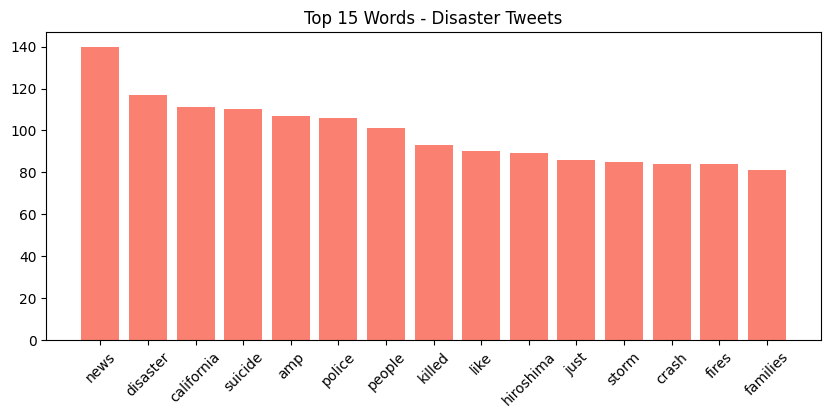

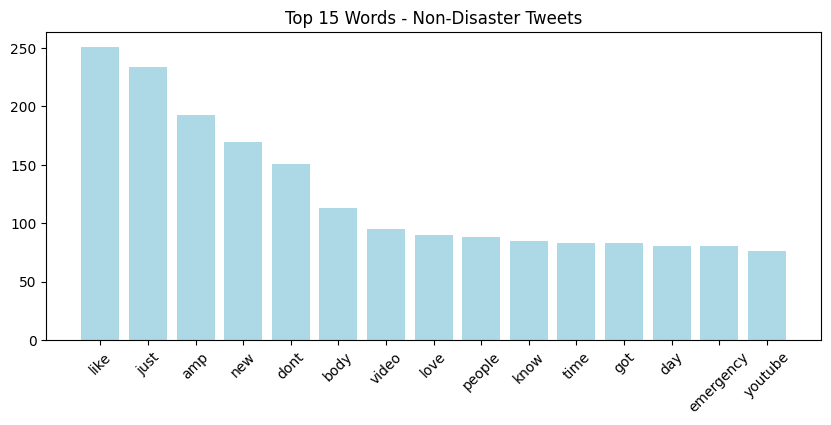

In [122]:
# Disaster
words_d, counts_d = zip(*disaster_counts.most_common(15))

plt.figure(figsize=(10,4))
plt.bar(words_d, counts_d, color='salmon')
plt.title("Top 15 Words - Disaster Tweets")
plt.xticks(rotation=45)
plt.show()

# Non-disaster
words_nd, counts_nd = zip(*non_disaster_counts.most_common(15))

plt.figure(figsize=(10,4))
plt.bar(words_nd, counts_nd, color='lightblue')
plt.title("Top 15 Words - Non-Disaster Tweets")
plt.xticks(rotation=45)
plt.show()


**Analysis**

Previously, the most frequent words in the dataset were primarily common function words (e.g., articles, prepositions, auxiliary verbs). These stopwords do not convey meaningful semantic information and therefore obscure the true lexical signal of the text.

After removing stopwords during preprocessing, the most frequent terms become significantly more informative. In disaster tweets, high-frequency words such as *news*, *disaster*, *police*, *killed*, *storm*, *crash*, and *fires* clearly reflect real-world emergency events and factual reporting language. This indicates strong semantic alignment between vocabulary usage and the disaster class.

In contrast, non-disaster tweets are dominated by conversational and informal language, including words such as *like*, *just*, *love*, *know*, *got*, and *youtube*. These terms reflect casual or expressive communication rather than event-based reporting.



#### **Section 2:**  Create a new boolean feature `has_url` that signals if a tweet contains a URL; check its relationship with `target`.

In [124]:
url_pattern = re.compile(url_regex)
df['has_url'] = df['text'].apply(lambda x: bool(url_pattern.search(x)))
print(df.groupby('target')['has_url'].mean())

target
0    0.416647
1    0.668105
Name: has_url, dtype: float64


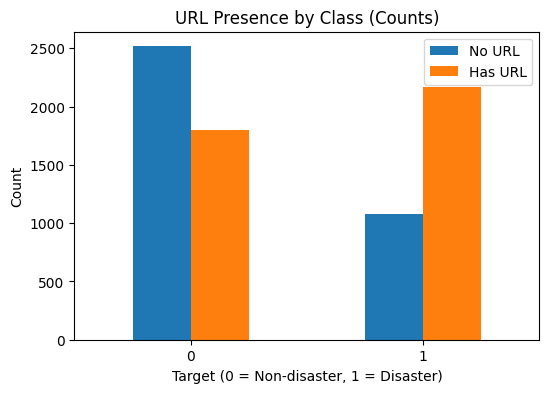

In [125]:
ct = pd.crosstab(df['target'], df['has_url'])

ct.plot(kind='bar', figsize=(6,4))
plt.title("URL Presence by Class (Counts)")
plt.xlabel("Target (0 = Non-disaster, 1 = Disaster)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(["No URL", "Has URL"])
plt.show()

**Analysis**

The distribution of URL presence across classes reveals a clear difference. Disaster-related tweets contain URLs more frequently than non-disaster tweets. Specifically, the number of tweets with URLs is substantially higher in the disaster class compared to the non-disaster class.

This pattern suggests that disaster tweets are often associated with external information sources, such as news articles, official reports, or real-time updates. Users may include links to provide evidence, share breaking news, or reference authoritative sources during emergency events.

In contrast, non-disaster tweets are more likely to be conversational or informal in nature, and therefore less dependent on external links.

#### **Section 3:**  Compute average word length per tweet and check if it differs by class.


In [126]:
def word_length_stats(s):
    lengths = []
    for w in simple_tokenize(s):
        lengths.append(len(w))
    if len(lengths) == 0:
        return 0
    else:
        return np.mean(lengths)
    
df['avg_word_len'] = df['text'].apply(lambda s: word_length_stats(s))
df.groupby('target')['avg_word_len'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4313.0,4.776469,1.066710,2.0000,4.055556,4.600000,5.312500,12.500000
1,3245.0,5.119448,0.931233,2.5625,4.466667,5.076923,5.636364,10.666667


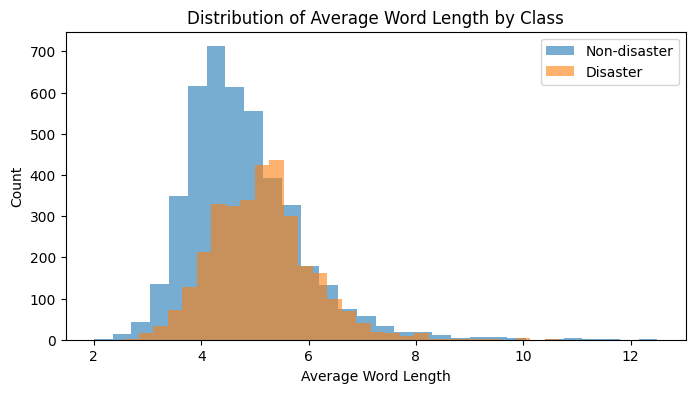

In [127]:
plt.figure(figsize=(8,4))

plt.hist(df[df['target']==0]['avg_word_len'], 
         bins=30, alpha=0.6, label='Non-disaster')

plt.hist(df[df['target']==1]['avg_word_len'], 
         bins=30, alpha=0.6, label='Disaster')

plt.legend()
plt.title("Distribution of Average Word Length by Class")
plt.xlabel("Average Word Length")
plt.ylabel("Count")
plt.show()

**Analysis**

The distribution of average word length per tweet shows substantial overlap between disaster and non-disaster classes. Although disaster tweets appear to have a slightly higher concentration around larger average word lengths, the difference is minimal and the distributions largely coincide.

This indicates that average word length does not provide strong discriminative power between the two classes. While disaster tweets may contain marginally longer words due to more formal or report-like language, the effect size is small and insufficient for reliable classification on its own.

## 7) Wrap-up & Further work
Suggestions for extension: build TF-IDF features, perform n-gram analysis (bigrams/trigrams), build a simple baseline classifier (Logistic Regression) and assess which EDA features help most.

----
*This notebook is intended for classroom use. It is heavily commented to help students read and understand each step.*